In [4]:
import cv2
import pandas 
import numpy as np
import matplotlib.pyplot as plt
import os


# under water collor correction 
### problems
- only blue green hues left in image 
- details blurred due to light scattering
- color casting due to less white light ref
---
### solution
- white balance correction
- red channel restor
- CLAHE
- dehazing
- unsharp maskin
- gama correction

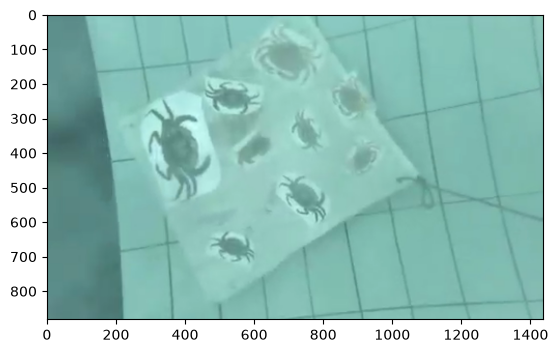

In [108]:
image  = cv2.imread('dataset/side_quest_2.png')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [99]:
def white_balance(img,Ashift,Bshift):
    # l = lightness A = green red B= blue yellow
    # convert to lab then shift a + b back to neutral
    lab = cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
    L,A,B = cv2.split(lab)
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    A = A - (np.mean(A) - 128)+Ashift
    B = B - (np.mean(B) - 128)+Bshift
    A = np.clip(A,0,255).astype(np.uint8)
    B = np.clip(B,0,255).astype(np.uint8)
    return cv2.cvtColor(cv2.merge([L , A , B]), cv2.COLOR_LAB2BGR)

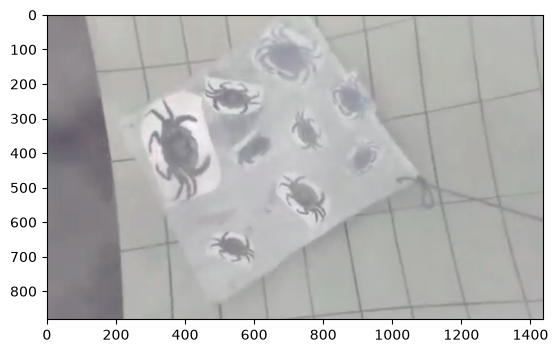

In [245]:
imgLabcorrection = white_balance(image,0,0)
plt.imshow(imgLabcorrection)
plt.show()

In [246]:
def restoreRed (img,redStrength):
    b,g,r = cv2.split(img)
    boost = cv2.equalizeHist(r)
    strength = redStrength/100.0
    rnew = cv2.addWeighted(r,1-strength,boost,strength,0)
    return cv2.merge([b,g,rnew])

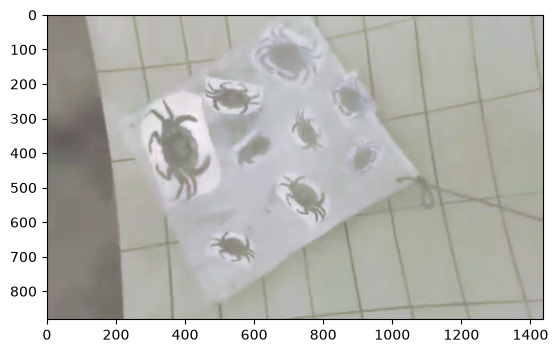

In [257]:
restoreRedimg = restoreRed(imgLabcorrection,12)
plt.imshow(restoreRedimg)
plt.show()

In [258]:
def clahe_enhance(img,Clip):
    #into tiles -> aapllies localization eith contrast clippin
    lab = cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
    L,A,B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit = max(Clip,0.1))
    l22 = clahe.apply(L)
    return cv2.cvtColor(cv2.merge([l22, A,B]),cv2.COLOR_LAB2BGR)




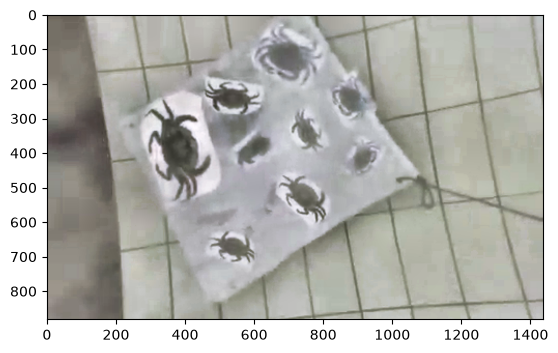

In [259]:
clahe = clahe_enhance(restoreRedimg,2)
plt.imshow(clahe)
plt.show()

In [260]:
def dehaze(img,mint,OMEGA):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    A = np.percentile(gray, 95)
    t = 1 - OMEGA * (gray / A)
    t = np.clip(t, mint, 1.0)
    t = cv2.merge([t, t, t])
    J = (img.astype(np.float32) - A) / t + A
    return np.clip(J, 0, 255).astype(np.uint8)

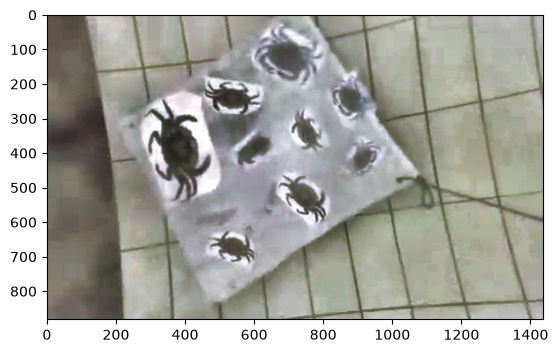

In [261]:
dehazedimg = dehaze(clahe,0.4,0.4)
plt.imshow(dehazedimg)
plt.show()

In [262]:
	
def sharpen(img):
    blur = cv2.GaussianBlur(img, (3, 3), 0)
    return cv2.addWeighted(img, 1.2, blur, -0.2, 0)

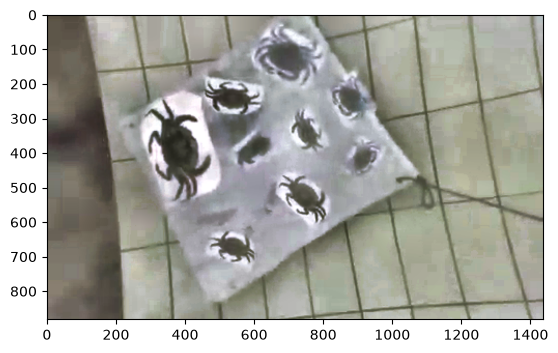

In [263]:
sharpenimg = sharpen(dehazedimg)
plt.imshow(sharpenimg)
plt.show()

In [264]:

def gamma_correct(img, g=1.1):
    inv = 1.0 / g
    table = np.array([(i / 255.0) ** inv * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

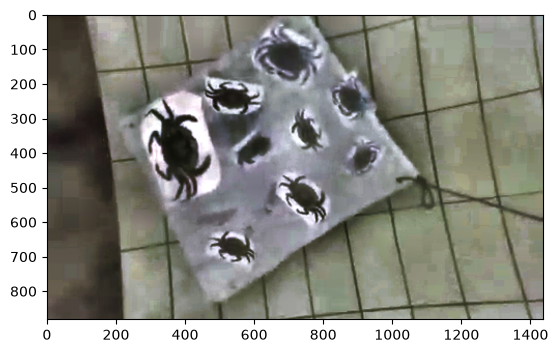

In [265]:
gammaimg =  gamma_correct(sharpenimg, g=0.7)
plt.imshow(gammaimg)
plt.show()

In [256]:
cv2.imshow('image', gammaimg)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
!git add .
!git commit -m "msh 3arfa azbt el 2rkam 3edel i quit"
!git push 